In [2]:
import pandas as pd
import folium
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import numpy as np
import os
import pickle

In [18]:
import glob 

def combine_csv_files(file_pattern):
    all_files = glob.glob(file_pattern)
    combined_df = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)
    combined_df = combined_df.drop_duplicates().reset_index(drop=True)
    return combined_df
location_df =combine_csv_files('C:\\NOA\\Data\\Ionosondes_*.csv')

In [19]:
location_df

,URSI,STATION NAME,EXAMPLE,LATITUDE,LONGITUDE
0,AN438,ANYANG,ionogram,37.39,126.95
1,AS00Q,ASCENSION ISLAND,ionogram,-7.95,345.60
2,AT138,ATHENS,ionogram,38.00,23.50
3,BC840,BOULDER,ionogram,40.00,254.70
4,RL052,CHILTON,ionogram,51.50,359.40
5,CO764,COLLEGE AK,ionogram,64.90,212.00
6,DB049,DOURBES,ionogram,50.10,4.60
7,DS932,DYESS AFB,ionogram,32.40,260.20
8,EG931,EGLIN AFB,ionogram,30.50,273.50
9,EA036,EL ARENOSILLO,ionogram,37.10,353.30


In [20]:
location_df['LONGc'] = location_df['LONGITUDE'].apply(pd.to_numeric, errors='coerce')
location_df['LONGc'] = location_df['LONGc'].apply(lambda x: x - 360 if x > 180 else x)

In [21]:
df = pd.read_csv("C:\\NOA\\Data\\Digisonde-Location.csv")
df = df.drop(columns=['Unnamed: 4'])
# print(df)
df['LONGc'] = df['LONG'].apply(pd.to_numeric, errors='coerce')
df['LONGc'] = df['LONGc'].apply(lambda x: x - 360 if x > 180 else x)

In [22]:
df

,URSI,STATION NAME,LAT,LONG,LONGc
0,AH223,AHMEDABAD,23.00,72.50,72.50
1,DH224,AL DHAFRA AFB,24.24,54.58,54.58
2,AL945,ALPENA,45.07,276.44,-83.56
3,AN438,ANYANG,37.39,126.95,126.95
4,AS00Q,ASCENSION ISLAND,-7.95,345.60,-14.40
...,...,...,...,...,...
123,WU430,WUHAN,30.50,114.40,114.40
124,XI434,XINXIANG CHINA,35.30,113.92,113.92
125,YA462,YAKUTSK,62.00,129.60,129.60
126,ZH466,ZHIGANSK,66.80,123.40,123.40


In [23]:
location_df

,URSI,STATION NAME,EXAMPLE,LATITUDE,LONGITUDE,LONGc
0,AN438,ANYANG,ionogram,37.39,126.95,126.95
1,AS00Q,ASCENSION ISLAND,ionogram,-7.95,345.60,-14.40
2,AT138,ATHENS,ionogram,38.00,23.50,23.50
3,BC840,BOULDER,ionogram,40.00,254.70,-105.30
4,RL052,CHILTON,ionogram,51.50,359.40,-0.60
5,CO764,COLLEGE AK,ionogram,64.90,212.00,-148.00
6,DB049,DOURBES,ionogram,50.10,4.60,4.60
7,DS932,DYESS AFB,ionogram,32.40,260.20,-99.80
8,EG931,EGLIN AFB,ionogram,30.50,273.50,-86.50
9,EA036,EL ARENOSILLO,ionogram,37.10,353.30,-6.70


c:\Users\mbabu\AppData\Local\anaconda3\envs\NN\Lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
C:\Users\mbabu\AppData\Local\Temp\ipykernel_24592\2433841365.py:8: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


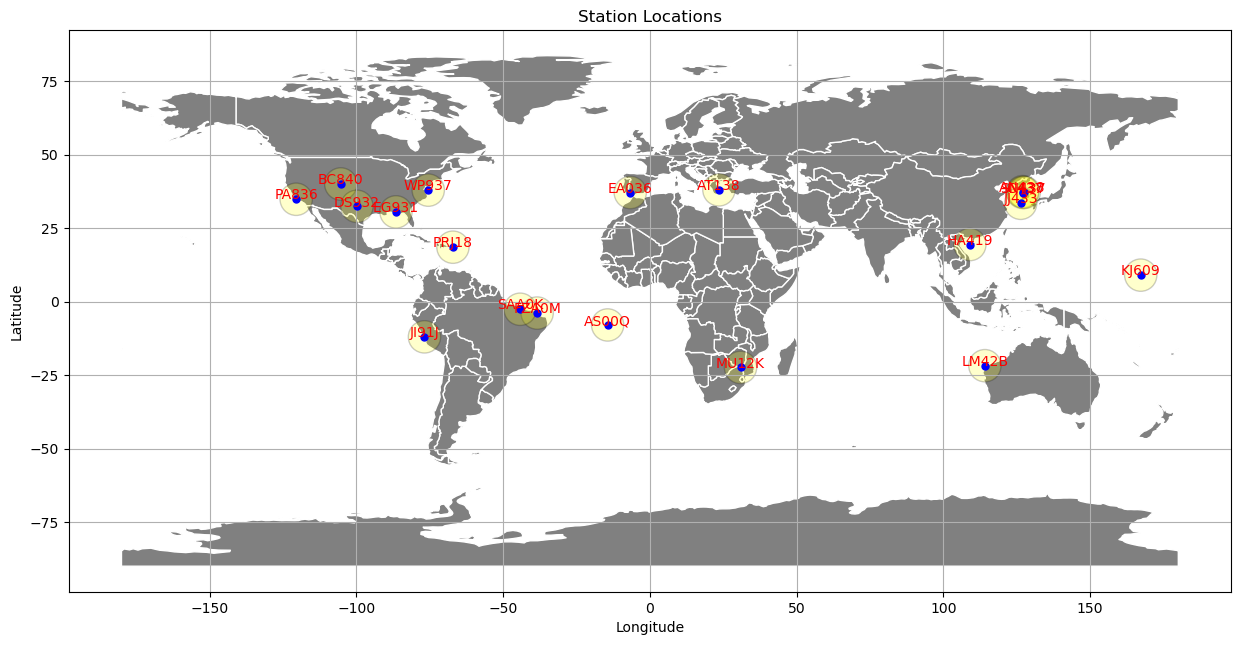

In [25]:

from matplotlib.patches import Circle
location_df = location_df[(location_df['LATITUDE'] >=-30) & (location_df['LATITUDE'] <=40)]
geometry = [Point(lon, lat) for lon, lat in zip(location_df['LONGc'], location_df['LATITUDE'])]
crs = {'init': 'epsg:4326'}  # WGS84 coordinate reference system
transmitter_gdf = gpd.GeoDataFrame(location_df, geometry=geometry, crs=crs)

# Create a global basemap
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Plot the world basemap
ax = world.plot(figsize=(15, 10), color='gray', edgecolor='white')

# Plot transmitter locations and add transmitter names as annotations
for index, row in transmitter_gdf.iterrows():
    ax.plot(row.geometry.x, row.geometry.y, marker='o', color='b', markersize=5)
    ax.text(row.geometry.x, row.geometry.y, row['URSI'],color = 'red', fontsize=10, ha='center')

# Plot circular areas around transmitter locations
for index, row in transmitter_gdf.iterrows():
    center_lat, center_lon = row['LATITUDE'], row['LONGc']
    radius_degrees = 5.5  # Radius in degrees
    circle = Circle((center_lon, center_lat), radius_degrees, edgecolor='k', facecolor='yellow', alpha=0.2)
    ax.add_patch(circle)

# Set plot title and display
plt.title('Station Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
# plt.savefig( f'C:\\NOA\\Analysis\\Ionosode_map-6years.png', dpi=300, bbox_inches='tight')
plt.show()


c:\Users\mbabu\AppData\Local\anaconda3\envs\NN\Lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
C:\Users\mbabu\AppData\Local\Temp\ipykernel_22268\3539630807.py:8: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


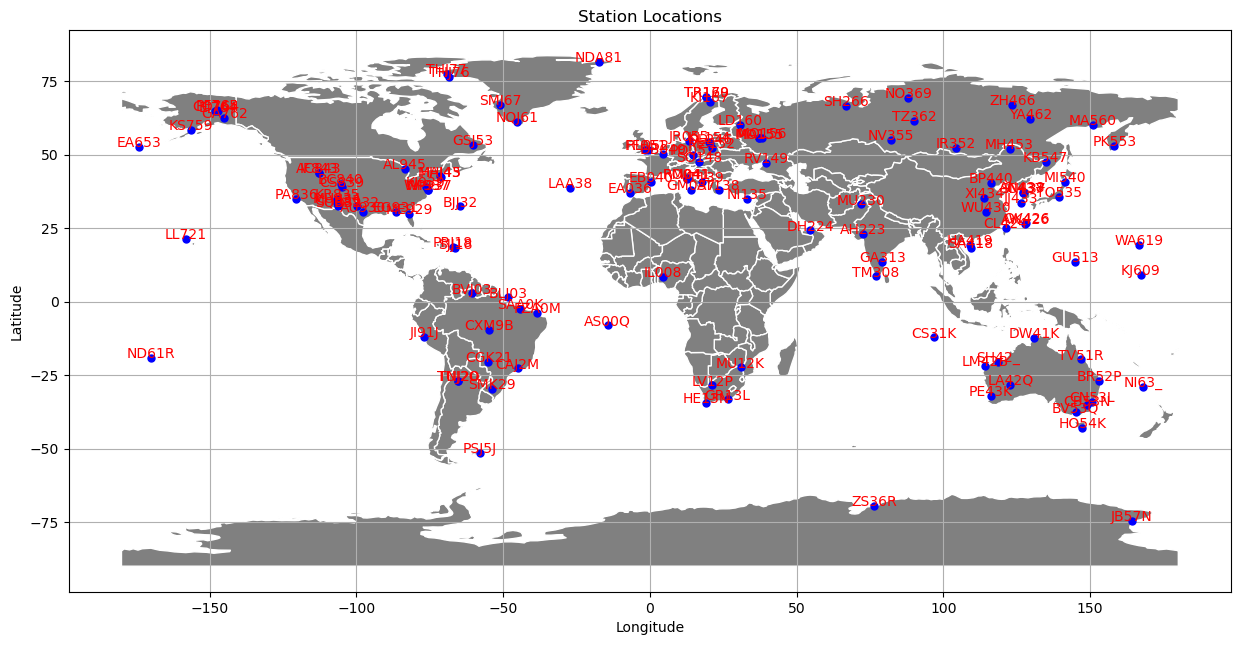

In [23]:

from matplotlib.patches import Circle

geometry = [Point(lon, lat) for lon, lat in zip(df['LONGc'], df['LAT'])]
crs = {'init': 'epsg:4326'}  # WGS84 coordinate reference system
transmitter_gdf = gpd.GeoDataFrame(df, geometry=geometry, crs=crs)

# Create a global basemap
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Plot the world basemap
ax = world.plot(figsize=(15, 10), color='gray', edgecolor='white')

# Plot transmitter locations and add transmitter names as annotations
for index, row in transmitter_gdf.iterrows():
    ax.plot(row.geometry.x, row.geometry.y, marker='o', color='b', markersize=5)
    ax.text(row.geometry.x, row.geometry.y, row['URSI'],color = 'red', fontsize=10, ha='center')

# Plot circular areas around transmitter locations
# for index, row in transmitter_gdf.iterrows():
#     center_lat, center_lon = row['LAT'], row['LONGc']
#     radius_degrees = 4  # Radius in degrees
#     circle = Circle((center_lon, center_lat), radius_degrees, edgecolor='k', facecolor='yellow', alpha=0.2)
#     ax.add_patch(circle)

# Set plot title and display
plt.title('Station Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.savefig( f'C:\\NOA\\Analysis\\Ionosode_map-1.png', dpi=300, bbox_inches='tight')
plt.show()


In [24]:
pd.read_pickle("E:\ASCII_lg-1132\\1132_026560_20050101_014337_20050101_021752_lg.pkl")

,datetime,geoc_lat,geoc_long
0,2005-01-01 01:43:36.606,70.9423,152.5599
1,2005-01-01 01:43:40.702,70.7172,152.2218
2,2005-01-01 01:43:44.798,70.4921,151.8836
3,2005-01-01 01:43:48.894,70.2670,151.5454
4,2005-01-01 01:43:52.990,70.0418,151.2073
...,...,...,...
496,2005-01-01 02:17:35.275,-49.9841,109.2667
497,2005-01-01 02:17:39.371,-50.2246,109.1618
498,2005-01-01 02:17:43.467,-50.4651,109.0570
499,2005-01-01 02:17:47.563,-50.7055,108.9522


In [55]:
pickle_folder = "E:\ASCII_lg-1132"
pickle_files = [file for file in os.listdir(pickle_folder) if file.endswith('.pkl')][1000:1010]

In [56]:
for file in pickle_files:
    pd.read_pickle(os.path.join(pickle_folder,file))

In [57]:
df

,URSI,STATION NAME,LAT,LONG,LONGc
0,AH223,AHMEDABAD,23.00,72.50,72.50
1,DH224,AL DHAFRA AFB,24.24,54.58,54.58
2,AL945,ALPENA,45.07,276.44,-83.56
3,AN438,ANYANG,37.39,126.95,126.95
4,AS00Q,ASCENSION ISLAND,-7.95,345.60,-14.40
...,...,...,...,...,...
123,WU430,WUHAN,30.50,114.40,114.40
124,XI434,XINXIANG CHINA,35.30,113.92,113.92
125,YA462,YAKUTSK,62.00,129.60,129.60
126,ZH466,ZHIGANSK,66.80,123.40,123.40


In [58]:
import math
from haversine import haversine, Unit

import pickle
# import tqdm 

def is_within_circle(lat, lon, center_lat, center_lon, radius_degrees):
    # Create tuples for the points
    point = (lat, lon)
    center = (center_lat, center_lon)

    # Calculate the distance in kilometers
    distance_km = haversine(point, center)

    # Convert radius from degrees to kilometers (approximation: 1 degree ≈ 111 km)
    radius_km = radius_degrees * 111

    # Check if the distance is within the radius
    return distance_km <= radius_km


# center_lat, center_lon = 15.826079, 121.27079
radius_degrees = 2.5

# # Assuming lat, lon are the coordinates of a point
# lat, lon = 15.9, 121.5
# within_circle = is_within_circle(lat, lon, center_lat, center_lon, radius_degrees)
# print("Is the point within the circle? ", within_circle)


results = []
processed_files = set()  # Set to keep track of processed pickle files

# Iterate over each pickle file
for pickle_file in pickle_files:
    # Skip processing) if the file has already been processed
    print(pickle_file)
    # if pickle_file in processed_files:
    #     continue
    
    with open(os.path.join(pickle_folder, pickle_file), 'rb') as f:
        orbit_data = pickle.load(f)
    
    # Flag to indicate if the condition was met for any row in the orbit file
    condition_met = False
    
    # Iterate over each latitude and longitude point in the pickle file
    for index, row in orbit_data.iterrows():
        row['geoc_long'] = float(row['geoc_long'])
        if row['geoc_long'] > 180:
            row['geoc_long'] -= 360
        # Check if the point is within the circular area of any transmitter
        for _, transmitter_row in df.iterrows():
            if is_within_circle(float(row['geoc_lat']), float(row['geoc_long']), 
                                transmitter_row['LAT'], transmitter_row['LONGc'], 
                                radius_degrees):
                # If the condition is satisfied, mark label as 1 and record transmitter name and orbit file location
                results.append({
                    'File Name': pickle_file,
                    'Label': 1,
                    'Station Name': transmitter_row['URSI'],
                    'Orbit Location': (float(row['geoc_lat']),float(row['geoc_long']))
                })
                
        if condition_met:
            # If the condition was met for any row, break out of the loop
            break

    if not condition_met:
        results.append({
            'File Name': pickle_file,
            'Label': 0,
            'Station Name': ' ',
            'Orbit Location': ' '
        })
    
    # Add the processed file to the set
    processed_files.add(pickle_file)

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Save DataFrame to CSV
results_df.to_csv('C:\\NOA\\Analysis\\matching_orbits_check.csv', index=False)

print("Matching orbits saved to 'matching_orbits.csv'")


1132_032680_20050212_033907_20050212_041425_lg.pkl
1132_032681_20050212_042837_20050212_050423_lg.pkl
1132_032690_20050212_051737_20050212_055454_lg.pkl
1132_032691_20050212_060737_20050212_064458_lg.pkl
1132_032700_20050212_065707_20050212_073523_lg.pkl
1132_032701_20050212_074707_20050212_082553_lg.pkl
1132_032710_20050212_083707_20050212_091553_lg.pkl
1132_032711_20050212_092707_20050212_100553_lg.pkl
1132_032720_20050212_101737_20050212_105554_lg.pkl
1132_032721_20050212_110737_20050212_114523_lg.pkl
Matching orbits saved to 'matching_orbits.csv'
